In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as st
import matplotlib.pyplot as plt
import re
import os

In [2]:
def rando_array(center,spread, n):
    spreadarray =np.tile(np.array([center,center-spread/2,center + spread/2,center,center-spread/4,center + spread/4]),n)
    subsetarray= spreadarray[0:n]
    return subsetarray 

def tbins(flt1, flt2, threshold):
    if flt1 >=threshold and flt2 >=threshold:
        return (3)
    if flt1 >= threshold or flt2 >= threshold:
        return (2)
    if flt1 < threshold and flt2 < threshold:
        return(1)
    else:
        print("input is not float between 0 and inf", flt1,flt2)      

def tbinscol(df):
    predictions=[]
    for i in range(0,len(df)):
        flt1 = df['value']['TargetP'][i]
        flt2 = df['value']['LOCALIZER'][i]
        prediction = tbins(flt1,flt2,0.5)
        predictions.append(prediction)
    return(predictions)

def alignmentstats(testdata):
    df = pd.read_csv(testdata, sep = "\t")
    df["Orthogroup"]= re.split("_",os.path.basename(testdata))[0]
    df["Species"]=df['ID'].apply(lambda x:re.split("_",x)[0])
    df = df.set_index(['Orthogroup','ID','Species','Algorithm','Organelle'])
    df=df.unstack(['Algorithm']).reset_index()
    df["Prediction"]= tbinscol(df)
    df = df.drop(columns=['ID','value'])
    df = pd.DataFrame(df.groupby(['Orthogroup','Organelle','Species'])['Prediction'].max())
    return(df)

def missing(lst1,lst2):
    missing=[]
    list2=lst2.split(", ")
    for item in lst1:
        if item not in list2:
            missing.append(item)
        elif item in list2:
            continue
        else:
            print("Not present or absent?!? Consult Schrodinger and/or his cats.Leave Pavlov's dog out of it.")
    m=", ".join(missing)
    return(m)

def unique(list):
    x = np.array(list)
    return(np.unique(x))       

def boxplotnames(columns,labels,names,color): #if you want species names next to points
    #sx = [np.random.normal(1 , 0.05, len(columns[0])), np.random.normal(2 , 0.05, len(columns[1]))] #If you want Gaussian jitter
    sx = [rando_array(1,0.1, len(columns[0])), rando_array(2,0.1, len(columns[1]))] # If you want uniform jitter
    fig, ax = plt.subplots()
    bplot = ax.boxplot(columns, labels= labels[0:2:1], patch_artist=True,widths=0.5, showfliers=False, zorder=1)
    palette =['green', "purple"]
    ax.set_ylim(-0.05,1.05)
    ax.set_ylabel(labels[2], fontsize= 9, fontweight='bold')
    ax.set_title(labels[3],fontsize= 9, fontweight='bold')
    ax.set_visible(True)
    for patch in bplot['boxes']:
        patch.set_facecolor(color)
    for x, val, name, c in zip(sx, columns,names,palette):
        plt.scatter(x, val, alpha=1, color=c, edgecolor = 'black', zorder=2)
        for i, txt in enumerate(name):##can enable this to add names to points if also pass a list of names
            ax.annotate(txt,(x[i]+0.075,val[i]-0.01),fontsize=4,color="blue")
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    ax.set_aspect(1.5)
    fig.set_size_inches(2.5, 2.5)
    plt.savefig(labels[4], format='svg', dpi=1200)
    plt.show()

def boxplot(columns,labels,color): #no names by points
    sx = [np.random.normal(1 , 0.05, len(columns[0])), np.random.normal(2 , 0.05, len(columns[1]))]
    fig, ax = plt.subplots()
    bplot = ax.boxplot(columns, labels= labels[0:2:1], patch_artist=True,widths=0.5, showfliers=False, zorder=1)
    palette =['seagreen', "purple"]
    ax.set_ylim(-0.1,1.1)
    ax.set_ylabel(labels[2], fontsize= 10, fontweight='bold')
    ax.set_title(labels[3],fontsize= 12, fontweight='bold')
    ax.set_visible(True)
    for patch in bplot['boxes']:
        patch.set_facecolor(color)
    for x, val, c in zip(sx, columns,palette):
        plt.scatter(x, val, alpha=1, color=c, edgecolor = 'black', zorder=2)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    ax.set_aspect(1.5)
    fig.set_size_inches(3, 3)
    plt.savefig(labels[4])
    plt.show()   

def fisher(df,factor,cols):
    dfcounts=df.loc[:,cols].groupby(factor).sum()
    oddsratio, pvalue = st.fisher_exact([[dfcounts.iloc[0,0], dfcounts.iloc[0,1]],[dfcounts.iloc[1,0],dfcounts.iloc[1,1]]])
    print(dfcounts,"\n","The Fisher's pvalue is", pvalue)


In [3]:
#Import descriptions for each orthogroup
descriptions = pd.read_csv("targeting_orthogroups.csv").iloc[:,[2,0,1]].rename(columns= {'group':'Orthogroup'})

#Import data from folder
dirlist= ["PLOTTING/first100bpAthal_predictions"]
allOGs = pd.DataFrame()
for directory in dirlist:
    for file in os.listdir(directory):
        if 'mostretargeted.txt' in file:
            print("processing ",file)
            data = alignmentstats("".join([directory,"/",file]))
            if not allOGs.empty:
                allOGs= pd.concat([allOGs, data])
            else:
                allOGs = data
        else:
            continue
allOGs.reset_index(inplace=True)
species = allOGs['Species'].drop_duplicates().tolist()
species
allOGs

processing  OG0000231_100bpAthalmostretargeted.txt
input is not float between 0 and inf nan 0.0
input is not float between 0 and inf nan 0.0
input is not float between 0 and inf nan 0.0
input is not float between 0 and inf nan 0.0
processing  OG0000664_100bpAthalmostretargeted.txt


/tmp/ipykernel_22831/785858292.py:32: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['ID','value'])
/tmp/ipykernel_22831/785858292.py:32: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['ID','value'])
/tmp/ipykernel_22831/785858292.py:32: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['ID','value'])


input is not float between 0 and inf nan 0.0
input is not float between 0 and inf nan 0.0
input is not float between 0 and inf nan 0.0
input is not float between 0 and inf nan 0.0
input is not float between 0 and inf nan 0.0
processing  OG0000955_100bpAthalmostretargeted.txt
input is not float between 0 and inf nan 0.0
input is not float between 0 and inf nan 0.0
processing  OG0000989_100bpAthalmostretargeted.txt
input is not float between 0 and inf nan 0.0
input is not float between 0 and inf nan 0.0
processing  OG0001068_100bpAthalmostretargeted.txt


/tmp/ipykernel_22831/785858292.py:32: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['ID','value'])
/tmp/ipykernel_22831/785858292.py:32: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['ID','value'])
/tmp/ipykernel_22831/785858292.py:32: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['ID','value'])


input is not float between 0 and inf nan 0.0
input is not float between 0 and inf nan 0.0
processing  OG0001259_100bpAthalmostretargeted.txt
input is not float between 0 and inf nan 0.0
input is not float between 0 and inf nan 0.0
processing  OG0001543_100bpAthalmostretargeted.txt
input is not float between 0 and inf nan 0.0
input is not float between 0 and inf nan 0.0
processing  OG0001566_100bpAthalmostretargeted.txt


...

processing  OG0010091_100bpAthalmostretargeted.txt
processing  OG0010106_100bpAthalmostretargeted.txt
processing  OG0010262_100bpAthalmostretargeted.txt
input is not float between 0 and inf nan 0.0
processing  OG0010520_100bpAthalmostretargeted.txt
processing  OG0010773_100bpAthalmostretargeted.txt


/tmp/ipykernel_22831/785858292.py:32: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['ID','value'])
/tmp/ipykernel_22831/785858292.py:32: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['ID','value'])
/tmp/ipykernel_22831/785858292.py:32: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['ID','value'])
/tmp/ipykernel_22831/785858292.py:32: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['ID','value'])
/tmp/ipykernel_22831/785858292.py:32: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['ID','value'])


processing  OG0010784_100bpAthalmostretargeted.txt
processing  OG0010966_100bpAthalmostretargeted.txt
processing  OG0011025_100bpAthalmostretargeted.txt
processing  OG0011039_100bpAthalmostretargeted.txt
processing  OG0011315_100bpAthalmostretargeted.txt
input is not float between 0 and inf nan 0.0
input is not float between 0 and inf nan 0.0
processing  OG0011320_100bpAthalmostretargeted.txt


/tmp/ipykernel_22831/785858292.py:32: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['ID','value'])
/tmp/ipykernel_22831/785858292.py:32: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['ID','value'])


,Orthogroup,Organelle,Species,Prediction
0,OG0000231,Chloroplast,Athal,3.0
1,OG0000231,Chloroplast,Bfungosa,3.0
2,OG0000231,Chloroplast,Eaphy,3.0
3,OG0000231,Chloroplast,Eroseum,2.0
4,OG0000231,Chloroplast,Hmono,3.0
...,...,...,...,...
3663,OG0011320,Mitochondria,Athal,1.0
3664,OG0011320,Mitochondria,Mesc,1.0
3665,OG0011320,Mitochondria,Pequestris,1.0
3666,OG0011320,Mitochondria,Rwill,1.0


In [4]:
combos=allOGs.loc[:,["Orthogroup","Organelle","Species"]].groupby(['Orthogroup','Organelle']).agg({
    'Species':', '.join
})
combos['Absent'] = combos.loc[:,"Species"].apply(lambda x:missing(species,x))    
absent= combos.drop(columns='Species').loc[combos['Absent'] != "",:]
absent2 = pd.DataFrame(absent.Absent.str.split(', ').tolist(), index=absent.index).stack().reset_index([0, 'Orthogroup','Organelle'])
absent2.columns= ['Orthogroup','Organelle','Species']
#absent2[['Gene','Aligned', 'Gaps', 'Total', 'Percent_Longest_Athal']] = "NaN"
absent2['Prediction']= 0
allOGs= pd.concat([allOGs,absent2])
allOGs= pd.merge(allOGs, descriptions,how="outer")
allOGs.head(5)

,Orthogroup,Organelle,Species,Prediction,targeting,description
0,OG0000231,Chloroplast,Athal,3.0,plastid control,ClpC1/C2/D
1,OG0000231,Chloroplast,Bfungosa,3.0,plastid control,ClpC1/C2/D
2,OG0000231,Chloroplast,Eaphy,3.0,plastid control,ClpC1/C2/D
3,OG0000231,Chloroplast,Eroseum,2.0,plastid control,ClpC1/C2/D
4,OG0000231,Chloroplast,Hmono,3.0,plastid control,ClpC1/C2/D


In [5]:
#check for NAs. 
#NAs may be due to there being prediction files for orthogroups that are not on .csv key
#i.e. tRNA processing enzymes that are not of interest for targeting
allOGs[allOGs.isna().any(axis=1)]

,Orthogroup,Organelle,Species,Prediction,targeting,description
78,OG0000989,Chloroplast,Athal,3.0,NaN,NaN
79,OG0000989,Chloroplast,Bfungosa,3.0,NaN,NaN
80,OG0000989,Chloroplast,Eaphy,3.0,NaN,NaN
81,OG0000989,Chloroplast,Eroseum,3.0,NaN,NaN
82,OG0000989,Chloroplast,Hmono,3.0,NaN,NaN
...,...,...,...,...,...,...
4499,OG0011315,Chloroplast,Pequestris,0.0,NaN,NaN
4500,OG0011315,Chloroplast,Rwill,0.0,NaN,NaN
4501,OG0011315,Mitochondria,Pequestris,0.0,NaN,NaN
4502,OG0011315,Mitochondria,Rwill,0.0,NaN,NaN


In [6]:
#Reformat and subset tables, rename columns

plot =allOGs[['description','targeting', 'Species','Organelle','Prediction']].dropna().drop_duplicates()
plot=plot.pivot(index=['targeting','description','Organelle'],columns='Species', values='Prediction')
plot= plot.reset_index().rename(columns ={
    'Atricho':'Amborella trichopoda',
    'Athal': 'A. thaliana*',
    'Bfungosa' : 'B. fungosa',
    'Caus' : 'Cuscuta australis',
    'Ccam' : 'Cuscuta campestris',
    'Dcari' : 'Dendropemon caribaeus',
    'Eaphy' : 'E. aphyllum',
    'Eroseum' : 'E. roseum',
    'Hmono' : 'M. hypopitys',
    'Itrif' : 'Ipomoea trifida',
    'Mesc' : 'M. esculenta',
    'Mgut' : 'Mimulus guttatus',
    'Moleifera' : 'Malania oleifera',
    'Osativa' : 'Oryza sativa',
    'Pequestris' : 'P. equestris',
    'Pjap' : 'Phtheirospermum japonicum',
    'Rcantleyi': 'R. cantleyi',
    'Rphallo': 'R. phalloides',
    'Rwill' : 'R. williamsianum',
    'Salbum': 'S. album',
    'Sasi': 'Striga asiatica',
    'Shimalayana': 'S. himalayana',
    'Spolyrhiza': 'Spirodela polyrhiza',
    'Valbum':'Viscum album',
    'Vvinifera': 'Vitis vinifera'
    })
plot2 = plot[['targeting','description','Organelle','A. thaliana*','P. equestris', 'E. aphyllum', 'E. roseum','M. esculenta','R. cantleyi','S. himalayana','S. album','R. phalloides','B. fungosa','R. williamsianum','M. hypopitys']].sort_values(['targeting','description']).set_index(['targeting','description'])
chloro = plot2.loc[plot2['Organelle']== 'Chloroplast'].drop(columns=['Organelle'])
mito = plot2.loc[plot2['Organelle']== 'Mitochondria'].drop(columns=['Organelle'])

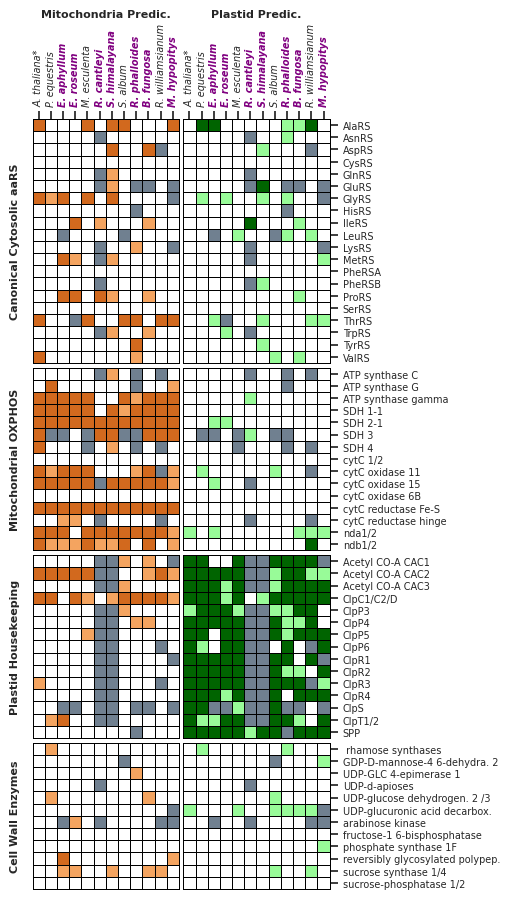

In [7]:
#Plot targeting on a gene-by-gene basis in a heatmap
holo = ['E. aphyllum','E. roseum','R. cantleyi','S. himalayana','R. phalloides','B. fungosa','M. hypopitys']

ratios = [len(chloro.loc['cytosolic']), len(chloro.loc['mitochondrial control']),len(chloro.loc['plastid control']),len(chloro.loc['cytosolic control'])]
radcolors =['slategrey','white','sandybrown','chocolate']
radcolors2 =['slategrey','white','palegreen','darkgreen']
sns.set_theme(rc={'figure.figsize':(7.5,10)})
fig, ax = plt.subplots(4, 2, gridspec_kw={'height_ratios': ratios})
fig.subplots_adjust(wspace= -0.65, hspace=.025)
mitotarget = sns.heatmap(mito.loc['cytosolic'],cmap=radcolors,linewidths=.5, linecolor='black',square=True,cbar=False,clip_on=False, ax=ax[0,0], yticklabels=1)
mitotarget.set_xlabel("Mitochondria Predic.", fontweight="bold", fontsize = 8) 
mitotarget.set_ylabel("Canonical Cytosolic aaRS",fontweight="bold", fontsize = 8,labelpad= -0.4)
mitotarget.xaxis.tick_top() # x axis on top
mitotarget.xaxis.set_label_position('top')
mitotarget.set_xticklabels(mitotarget.get_xticklabels(), rotation=90,fontsize = 7)
mitotarget.set_yticklabels("")
for text in mitotarget.get_xticklabels():
    text.set_style('italic')
    if text.get_text() in holo:
        text.set_weight('bold')
        text.set_color('purple')
    elif text.get_text() in ["Arabidopsis thaliana*"]:
        text.set_weight('bold')

chlorotarget = sns.heatmap(chloro.loc['cytosolic'],cmap=radcolors2,linewidths=.5,cbar=False,square=True, linecolor='black', clip_on=False,ax=ax[0,1], yticklabels=1) 
#chlorotarget.set_yticklabels(chlorotarget.get_yticklabels(),fontsize = 10)
chlorotarget.set_xlabel("Plastid Predic.", fontweight="bold", fontsize = 8) 
chlorotarget.set_ylabel("",fontweight="bold", )
chlorotarget.yaxis.set_label_position("right")
chlorotarget.xaxis.tick_top() # x axis on top
chlorotarget.xaxis.set_label_position('top')
chlorotarget.set_xticklabels(chlorotarget.get_xticklabels(), rotation=90,fontsize = 7)
chlorotarget.yaxis.tick_right()
chlorotarget.set_yticklabels(chlorotarget.get_yticklabels(),rotation = 0,fontsize = 7)
for text in chlorotarget.get_xticklabels():
    text.set_style('italic')
    if text.get_text() in holo:
        text.set_weight('bold')
        text.set_color('purple')
    elif text.get_text() in ["Arabidopsis thaliana*"]:
        text.set_weight('bold')

mitocontrol = sns.heatmap(mito.loc['mitochondrial control'],cmap=radcolors,linewidths=.5,square= True, linecolor='black',cbar=False,clip_on=False, ax=ax[1,0])
mitocontrol.set_ylabel("Mitochondrial OXPHOS", fontweight="bold", fontsize = 8, labelpad= -0.4)
mitocontrol.xaxis.label.set_visible(False)
mitocontrol.set_xticklabels("")
mitocontrol.set_yticklabels("")

chlorocontrol = sns.heatmap(chloro.loc['mitochondrial control'],cmap=radcolors2,linewidths=.5,square= True, cbar=False, linecolor='black', clip_on=False,ax=ax[1,1], yticklabels=1) 
chlorocontrol.set_ylabel("")
chlorocontrol.yaxis.tick_right()
chlorocontrol.xaxis.label.set_visible(False)
chlorocontrol.set_xticklabels("")
chlorocontrol.set_yticklabels(chlorocontrol.get_yticklabels(),rotation = 0,fontsize = 7)

mitoplastidcontrol = sns.heatmap(mito.loc['plastid control'],cmap=radcolors,linewidths=.5,square= True, linecolor='black',cbar=False,clip_on=False, ax=ax[2,0])
mitoplastidcontrol.set_ylabel("Plastid Housekeeping", fontweight="bold", fontsize = 8, labelpad= -0.4)
mitoplastidcontrol.xaxis.label.set_visible(False)
mitoplastidcontrol.set_xticklabels("")
mitoplastidcontrol.set_yticklabels("")

chloroplastidcontrol = sns.heatmap(chloro.loc['plastid control'],cmap=radcolors2,linewidths=.5,square= True, linecolor='black',cbar=False,clip_on=False, ax=ax[2,1], yticklabels=1)
chloroplastidcontrol.set_ylabel("", fontweight="bold")
chloroplastidcontrol.yaxis.tick_right()
chloroplastidcontrol.xaxis.label.set_visible(False)
chloroplastidcontrol.set_xticklabels("")
chloroplastidcontrol.set_yticklabels(chloroplastidcontrol.get_yticklabels(),rotation = 0,fontsize = 7)


mitocytocontrol = sns.heatmap(mito.loc['cytosolic control'],cmap=radcolors,linewidths=.5,square= True, linecolor='black',cbar=False,clip_on=False, ax=ax[3,0])
mitocytocontrol.set_ylabel("Cell Wall Enzymes", fontweight="bold", fontsize = 8, labelpad= -0.4)
mitocytocontrol.xaxis.label.set_visible(False)
mitocytocontrol.set_xticklabels("")
mitocytocontrol.set_yticklabels("")

radcolors3 =['slategrey','white','palegreen']
chlorocytocontrol = sns.heatmap(chloro.loc['cytosolic control'],cmap=radcolors3,linewidths=.5,square= True, cbar=False, linecolor='black', clip_on=False,ax=ax[3,1],yticklabels=1) 
chlorocytocontrol.set_ylabel("")
chlorocytocontrol.yaxis.set_label_position("right")
chlorocytocontrol.xaxis.label.set_visible(False)
chlorocytocontrol.set_xticklabels("")
chlorocytocontrol.yaxis.tick_right()
chlorocytocontrol.set_yticklabels(chlorocytocontrol.get_yticklabels(),rotation = 0,fontsize = 7)

plt.savefig('20240819_retargeting_aaRS_cutoff0.50.svg', dpi=600)

In [8]:
#Remove A thaliana, then save retargeting matrix
chloro= chloro.drop(columns = "A. thaliana*")
mito= mito.drop(columns = "A. thaliana*")
chloro.to_csv("20240819_retargetingmatrix_chloro.csv")
mito.to_csv("20240819_retargetingmatrix_mito.csv")

In [9]:
#replace numeric codes with descriptive strings
group = ['targeting_unknown','notarget','target','target']
mitobins = mito.replace([0,1,2,3],group)
chlorobins = chloro.replace([0,1,2,3],group)
mitobins

Species                                  P. equestris        E. aphyllum  \
targeting       description                                                
Chlorophyll     1. CHLD                      notarget             target   
                1. CHLH                      notarget             target   
                1. CHLI                      notarget           notarget   
                1. GUN4                        target           notarget   
                2. CHLM                      notarget           notarget   
...                                               ...                ...   
tRNA_processing GatB                           target             target   
                GatC                           target  targeting_unknown   
                putative MTF                   target           notarget   
                putative Tils                notarget             target   
                tRNaseZ3/4 mito/nuclear        target           notarget   

Species                                           E. roseum M. esculenta  \
targeting       description                                                
Chlorophyll     1. CHLD                            notarget     notarget   
                1. CHLH                   targeting_unknown     notarget   
                1. CHLI                              target       target   
                1. GUN4                              target     notarget   
                2. CHLM                            notarget     notarget   
...                                                     ...          ...   
tRNA_processing GatB                                 target       target   
                GatC                                 target       target   
                putative MTF              targeting_unknown       target   
                putative Tils                        target       target   
                tRNaseZ3/4 mito/nuclear            notarget       target   

Species                                         R. cantleyi  \
targeting       description                                   
Chlorophyll     1. CHLD                   targeting_unknown   
                1. CHLH                   targeting_unknown   
                1. CHLI                   targeting_unknown   
                1. GUN4                   targeting_unknown   
                2. CHLM                   targeting_unknown   
...                                                     ...   
tRNA_processing GatB                      targeting_unknown   
                GatC                      targeting_unknown   
                putative MTF                       notarget   
                putative Tils             targeting_unknown   
                tRNaseZ3/4 mito/nuclear   targeting_unknown   

Species                                       S. himalayana  S. album  \
targeting       description                                             
Chlorophyll     1. CHLD                   targeting_unknown  notarget   
                1. CHLH                   targeting_unknown  notarget   
                1. CHLI                   targeting_unknown  notarget   
                1. GUN4                   targeting_unknown  notarget   
                2. CHLM                   targeting_unknown  notarget   
...                                                     ...       ...   
tRNA_processing GatB                      targeting_unknown    target   
                GatC                      targeting_unknown    target   
                putative MTF                         target    target   
                putative Tils             targeting_unknown    target   
                tRNaseZ3/4 mito/nuclear              target    target   

Species                                       R. phalloides  \
targeting       description                                   
Chlorophyll     1. CHLD                   targeting_unknown   
                1. CHLH                   targeting_unknown   


In [10]:
#format dataframe for plotting
metacounts= pd.DataFrame()
for i in unique(mitobins.index.get_level_values('targeting')):
    counts=pd.DataFrame(
            {"targeting": i,
             "group" : group[0:3],}).set_index(['targeting','group'])
    for col in mitobins.loc[i,:].columns:
        count = mitobins.loc[i,:].groupby(col).size().to_frame(col).rename_axis('group')
        #print(count)
        counts = counts.join(count)
    metacounts= pd.concat([metacounts,counts])
metacounts=metacounts.fillna(0)
metacountstsimple = metacounts.transpose()
metabolism =[]
for ind in metacountstsimple.index:
    if ind in holo:
        metabolism.append("heterotroph")
    else:
        metabolism.append("autotroph")
metacountstsimple['metabolism'] = metabolism
metacountstsimple = metacountstsimple.set_index(['metabolism',metacountstsimple.index]).sort_index()



/tmp/ipykernel_22831/785858292.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(columns, labels= labels[0:2:1], patch_artist=True,widths=0.5, showfliers=False, zorder=1)


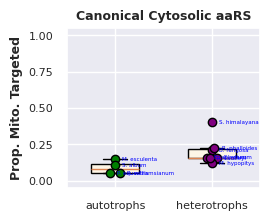

group                         targeting_unknown  notarget  target     ratio
metabolism                                                                 
autotroph   M. esculenta                    0.0      17.0     3.0  0.150000
            P. equestris                    0.0      19.0     1.0  0.050000
            R. williamsianum                1.0      18.0     1.0  0.052632
            S. album                        1.0      17.0     2.0  0.105263
heterotroph B. fungosa                      1.0      15.0     4.0  0.210526
            E. aphyllum                     1.0      16.0     3.0  0.157895
            E. roseum                       1.0      16.0     3.0  0.157895
            M. hypopitys                    3.0      15.0     2.0  0.117647
            R. cantleyi                     7.0      11.0     2.0  0.153846
            R. phalloides                   2.0      14.0     4.0  0.222222
            S. himalayana                   0.0      12.0     8.0  0.400000


/tmp/ipykernel_22831/785858292.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(columns, labels= labels[0:2:1], patch_artist=True,widths=0.5, showfliers=False, zorder=1)


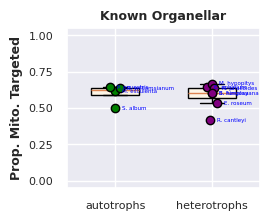

/tmp/ipykernel_22831/785858292.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(columns, labels= labels[0:2:1], patch_artist=True,widths=0.5, showfliers=False, zorder=1)


group                         targeting_unknown  notarget  target     ratio
metabolism                                                                 
autotroph   M. esculenta                    2.0       5.0     8.0  0.615385
            P. equestris                    1.0       5.0     9.0  0.642857
            R. williamsianum                4.0       4.0     7.0  0.636364
            S. album                        1.0       7.0     7.0  0.500000
heterotroph B. fungosa                      0.0       6.0     9.0  0.600000
            E. aphyllum                     1.0       5.0     9.0  0.642857
            E. roseum                       0.0       7.0     8.0  0.533333
            M. hypopitys                    0.0       5.0    10.0  0.666667
            R. cantleyi                     3.0       7.0     5.0  0.416667
            R. phalloides                   4.0       4.0     7.0  0.636364
            S. himalayana                   0.0       6.0     9.0  0.600000


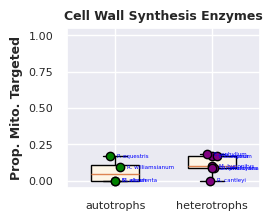

group                         targeting_unknown  notarget  target     ratio
metabolism                                                                 
autotroph   M. esculenta                    0.0      12.0     0.0  0.000000
            P. equestris                    0.0      10.0     2.0  0.166667
            R. williamsianum                1.0      10.0     1.0  0.090909
            S. album                        1.0      11.0     0.0  0.000000
heterotroph B. fungosa                      0.0      10.0     2.0  0.166667
            E. aphyllum                     1.0       9.0     2.0  0.181818
            E. roseum                       0.0      10.0     2.0  0.166667
            M. hypopitys                    2.0       9.0     1.0  0.100000
            R. cantleyi                     2.0      10.0     0.0  0.000000
            R. phalloides                   0.0      11.0     1.0  0.083333
            S. himalayana                   0.0      11.0     1.0  0.083333


/tmp/ipykernel_22831/785858292.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(columns, labels= labels[0:2:1], patch_artist=True,widths=0.5, showfliers=False, zorder=1)


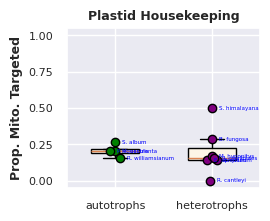

group                         targeting_unknown  notarget  target     ratio
metabolism                                                                 
autotroph   M. esculenta                    0.0      12.0     3.0  0.200000
            P. equestris                    0.0      12.0     3.0  0.200000
            R. williamsianum                2.0      11.0     2.0  0.153846
            S. album                        0.0      11.0     4.0  0.266667
heterotroph B. fungosa                      1.0      10.0     4.0  0.285714
            E. aphyllum                     1.0      12.0     2.0  0.142857
            E. roseum                       1.0      12.0     2.0  0.142857
            M. hypopitys                    3.0      10.0     2.0  0.166667
            R. cantleyi                    13.0       2.0     0.0  0.000000
            R. phalloides                   2.0      11.0     2.0  0.153846
            S. himalayana                  13.0       1.0     1.0  0.500000


In [11]:
#plot mitotargeting predictions
aaRS = metacountstsimple['cytosolic'].assign(ratio=lambda metacountstsimple: metacountstsimple.target/(metacountstsimple.notarget + metacountstsimple.target)).sort_index()
aaRSspecies = aaRSdata = [aaRS.loc['autotroph',].index.values.tolist(),aaRS.loc['heterotroph',].index.values.tolist()]
aaRSdata = [aaRS.loc['autotroph','ratio'].values.tolist(),aaRS.loc['heterotroph','ratio'].values.tolist()]
aaRSlabels = ['autotrophs', 'heterotrophs', 'Prop. Mito. Targeted','Canonical Cytosolic aaRS',"Mito_ProportionRetargeted_cytaaRS.svg"]
boxplotnames(aaRSdata,aaRSlabels,aaRSspecies,'oldlace')
print(aaRS)

mitocontrols = metacountstsimple['mitochondrial control'].assign(ratio=lambda metacountstsimple: metacountstsimple.target/(metacountstsimple.notarget + metacountstsimple.target)).sort_index()
mitocontrolsdata = [mitocontrols.loc['autotroph','ratio'].values.tolist(),mitocontrols.loc['heterotroph','ratio'].values.tolist()]
mitocontrolslabels = ['autotrophs', 'heterotrophs', 'Prop. Mito. Targeted','Known Organellar',"Mito_ProportionRetargeted_OXPHOS.svg"]
boxplotnames(mitocontrolsdata,mitocontrolslabels,aaRSspecies,'oldlace')
print(mitocontrols)

cytocontrols = metacountstsimple['cytosolic control'].assign(ratio=lambda metacountstsimple: metacountstsimple.target/(metacountstsimple.notarget + metacountstsimple.target)).sort_index()
cytocontrolsdata = [cytocontrols.loc['autotroph','ratio'].values.tolist(),cytocontrols.loc['heterotroph','ratio'].values.tolist()]
cytocontrolslabels = ['autotrophs', 'heterotrophs', 'Prop. Mito. Targeted','Cell Wall Synthesis Enzymes',"Mito_ProportionRetargeted_Cellwall.svg"]
boxplotnames(cytocontrolsdata,cytocontrolslabels,aaRSspecies,'oldlace')
print(cytocontrols)

chlorocontrols = metacountstsimple['plastid control'].assign(ratio=lambda metacountstsimple: metacountstsimple.target/(metacountstsimple.notarget + metacountstsimple.target)).sort_index()
chlorocontrols
chlorocontrolsdata = [chlorocontrols.loc['autotroph','ratio'].values.tolist(),chlorocontrols .loc['heterotroph','ratio'].values.tolist()]
chlorocontrolslabels = ['autotrophs', 'heterotrophs', 'Prop. Mito. Targeted','Plastid Housekeeping',"Mito_ProportionRetargeted_PlastidHousekeeping.svg"]
boxplotnames(chlorocontrolsdata,chlorocontrolslabels,aaRSspecies,'oldlace')
print(chlorocontrols)

In [12]:
#means
print("aaRS_auto",np.round(np.mean(aaRS.loc['autotroph','ratio'].values.tolist()),3),
"aaRS_hetero",np.round(np.mean(aaRS.loc['heterotroph','ratio'].values.tolist()),3),"\n"
"mitocontrols_auto",np.round(np.mean(mitocontrols.loc['autotroph','ratio'].values.tolist()),3),
"mitocontrols_hetero",np.round(np.mean(mitocontrols.loc['heterotroph','ratio'].values.tolist()),3),"\n"
"cytocontrols_auto",np.round(np.mean(cytocontrols.loc['autotroph','ratio'].values.tolist()),3),
"cytocontrols_hetero",np.round(np.mean(cytocontrols.loc['heterotroph','ratio'].values.tolist()),3),"\n"
"chlorocontrols_auto",np.round(np.mean(chlorocontrols.loc['autotroph','ratio'].values.tolist()),3),
"chlorocontrols_hetero",np.round(np.mean(chlorocontrols.loc['heterotroph','ratio'].values.tolist()),3))

aaRS_auto 0.089 aaRS_hetero 0.203 
mitocontrols_auto 0.599 mitocontrols_hetero 0.585 
cytocontrols_auto 0.064 cytocontrols_hetero 0.112 
chlorocontrols_auto 0.205 chlorocontrols_hetero 0.199


In [13]:
## Statistics
#normality
print(np.round(st.shapiro(aaRS.loc['autotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(aaRS.loc['heterotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(mitocontrols.loc['autotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(mitocontrols.loc['heterotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(cytocontrols.loc['autotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(cytocontrols.loc['heterotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(chlorocontrols.loc['autotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(chlorocontrols.loc['heterotroph','ratio'].values.tolist())[1],3))

0.335 0.03 0.061 0.134 0.275 0.314 0.59 0.194


In [14]:
#t-test
stat1, pvalue1 = st.ttest_ind(aaRS.loc['autotroph','ratio'].values.tolist(),aaRS.loc['heterotroph','ratio'].values.tolist(),equal_var=False, alternative='less')
stat2, pvalue2 = st.ttest_ind(mitocontrols.loc['autotroph','ratio'].values.tolist(),mitocontrols.loc['heterotroph','ratio'].values.tolist(),equal_var=False,alternative='less')
stat3, pvalue3 =st.ttest_ind(cytocontrols.loc['autotroph','ratio'].values.tolist(),cytocontrols.loc['heterotroph','ratio'].values.tolist(),equal_var=False,alternative="less")
stat4, pvalue4 =st.ttest_ind(chlorocontrols.loc['autotroph','ratio'].values.tolist(),chlorocontrols.loc['heterotroph','ratio'].values.tolist(),equal_var=False,alternative="less")

print("auto vs. hetero aaRS: ", np.round(pvalue1,3),"\n",
    "auto vs. hetero OXPHOS: ", np.round(pvalue2,3), "\n",
    "auto vs. hetero cell wall: ", np.round(pvalue3,3), "\n",
    "auto vs. hetero plastid: ", np.round(pvalue4,3), "\n")

auto vs. hetero aaRS:  0.013 
 auto vs. hetero OXPHOS:  0.611 
 auto vs. hetero cell wall:  0.18 
 auto vs. hetero plastid:  0.538 



In [15]:
#non-parametric test
stat1, pvalue1m = st.mannwhitneyu(aaRS.loc['autotroph','ratio'].values.tolist(),aaRS.loc['heterotroph','ratio'].values.tolist())
stat2, pvalue2m = st.mannwhitneyu(mitocontrols.loc['autotroph','ratio'].values.tolist(),mitocontrols.loc['heterotroph','ratio'].values.tolist())
stat3, pvalue3m =st.mannwhitneyu(cytocontrols.loc['autotroph','ratio'].values.tolist(),cytocontrols.loc['heterotroph','ratio'].values.tolist())
stat4, pvalue4m =st.mannwhitneyu(chlorocontrols.loc['autotroph','ratio'].values.tolist(),chlorocontrols.loc['heterotroph','ratio'].values.tolist())


print("auto vs. hetero aaRS: ", np.round(pvalue1m,3),"\n",
    "auto vs. hetero OXPHOS: ", np.round(pvalue2m,3), "\n",
    "auto vs. hetero cell wall: ", np.round(pvalue3m,3), "\n",
    "auto vs. hetero chloro controls: ", np.round(pvalue4m,3), "\n")

auto vs. hetero aaRS:  0.018 
 auto vs. hetero OXPHOS:  0.924 
 auto vs. hetero cell wall:  0.385 
 auto vs. hetero chloro controls:  0.447 



In [16]:
#Fisher's exact test
print("############aaRS############")
fisher(aaRS,'metabolism',['notarget','target'])
print("############OXPHOS##########")
fisher(mitocontrols,'metabolism',['notarget','target'])
print("############Cell Wall########")
fisher(cytocontrols,'metabolism',['notarget','target'])

############aaRS############
group        notarget  target
metabolism                   
autotroph        71.0     7.0
heterotroph      99.0    26.0 
 The Fisher's pvalue is 0.03122025380516106
############OXPHOS##########
group        notarget  target
metabolism                   
autotroph        21.0    31.0
heterotroph      40.0    57.0 
 The Fisher's pvalue is 1.0
############Cell Wall########
group        notarget  target
metabolism                   
autotroph        43.0     3.0
heterotroph      70.0     9.0 
 The Fisher's pvalue is 0.5327610939993477


In [17]:
#format table for plotting
cmetacounts= pd.DataFrame()
for i in unique(chlorobins.index.get_level_values('targeting')):
    counts=pd.DataFrame(
            {"targeting": i,
             "group" : group[0:3],}).set_index(['targeting','group'])
    for col in chlorobins.loc[i,:].columns:
        count = chlorobins.loc[i,:].groupby(col).size().to_frame(col).rename_axis('group')
        #print(count)
        counts = counts.join(count)
    cmetacounts= pd.concat([cmetacounts,counts])
cmetacounts=cmetacounts.fillna(0)
cmetacountstsimple = cmetacounts.transpose()
metabolism =[]
for ind in cmetacountstsimple.index:
    if ind in holo:
        metabolism.append("heterotroph")
    else:
        metabolism.append("autotroph")
cmetacountstsimple['metabolism'] = metabolism
cmetacountstsimple = cmetacountstsimple.set_index(['metabolism',cmetacountstsimple.index]).sort_index()


#Print Data for Rafflesiaceae
Raffleceaceae_metacountstsimple=cmetacountstsimple[["cytosolic","cytosolic control","plastid control"]].iloc[cmetacountstsimple.index.get_level_values(1).isin(['R. cantleyi', 'S. himalayana'])]
print(Raffleceaceae_metacountstsimple['cytosolic'].assign(ratio=lambda Raffleceaceae_metacountstsimple: Raffleceaceae_metacountstsimple.target/(Raffleceaceae_metacountstsimple.notarget + Raffleceaceae_metacountstsimple.target)).sort_values('ratio'))
print(Raffleceaceae_metacountstsimple['cytosolic control'].assign(ratio=lambda Raffleceaceae_metacountstsimple: Raffleceaceae_metacountstsimple.target/(Raffleceaceae_metacountstsimple.notarget + Raffleceaceae_metacountstsimple.target)).sort_values('ratio'))
print(Raffleceaceae_metacountstsimple['plastid control'].assign(ratio=lambda Raffleceaceae_metacountstsimple: Raffleceaceae_metacountstsimple.target/(Raffleceaceae_metacountstsimple.notarget + Raffleceaceae_metacountstsimple.target)).sort_values('ratio'))

group                      targeting_unknown  notarget  target     ratio
metabolism                                                              
heterotroph R. cantleyi                  7.0      12.0     1.0  0.076923
            S. himalayana                0.0      14.0     6.0  0.300000
group                      targeting_unknown  notarget  target  ratio
metabolism                                                           
heterotroph R. cantleyi                  2.0      10.0     0.0    0.0
            S. himalayana                0.0      12.0     0.0    0.0
group                      targeting_unknown  notarget  target  ratio
metabolism                                                           
heterotroph R. cantleyi                 13.0       1.0     1.0    0.5
            S. himalayana               13.0       0.0     2.0    1.0


In [18]:
#drop Rafflesiaceae (S himilayana and R cantleyi) for this because they don't have plastomes
cmetacountstsimple=cmetacountstsimple.iloc[~cmetacountstsimple.index.get_level_values(1).isin(['R. cantleyi', 'S. himalayana'])]


/tmp/ipykernel_22831/785858292.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(columns, labels= labels[0:2:1], patch_artist=True,widths=0.5, showfliers=False, zorder=1)


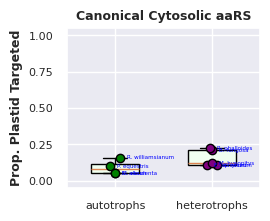

/tmp/ipykernel_22831/785858292.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(columns, labels= labels[0:2:1], patch_artist=True,widths=0.5, showfliers=False, zorder=1)


group                         targeting_unknown  notarget  target     ratio
metabolism                                                                 
autotroph   M. esculenta                    0.0      19.0     1.0  0.050000
            P. equestris                    0.0      18.0     2.0  0.100000
            R. williamsianum                1.0      16.0     3.0  0.157895
            S. album                        1.0      18.0     1.0  0.052632
heterotroph B. fungosa                      1.0      15.0     4.0  0.210526
            E. aphyllum                     1.0      17.0     2.0  0.105263
            E. roseum                       1.0      17.0     2.0  0.105263
            M. hypopitys                    3.0      15.0     2.0  0.117647
            R. phalloides                   2.0      14.0     4.0  0.222222


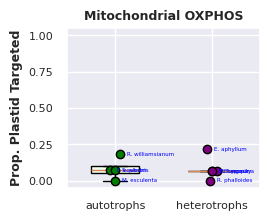

group                         targeting_unknown  notarget  target     ratio
metabolism                                                                 
autotroph   M. esculenta                    2.0      13.0     0.0  0.000000
            P. equestris                    1.0      13.0     1.0  0.071429
            R. williamsianum                4.0       9.0     2.0  0.181818
            S. album                        1.0      13.0     1.0  0.071429
heterotroph B. fungosa                      0.0      14.0     1.0  0.066667
            E. aphyllum                     1.0      11.0     3.0  0.214286
            E. roseum                       0.0      14.0     1.0  0.066667
            M. hypopitys                    0.0      14.0     1.0  0.066667
            R. phalloides                   4.0      11.0     0.0  0.000000
[['M. esculenta', 'P. equestris', 'R. williamsianum', 'S. album'], ['B. fungosa', 'E. aphyllum', 'E. roseum', 'M. hypopitys', 'R. phalloides']]
[[0.0, 0.07142857142

/tmp/ipykernel_22831/785858292.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(columns, labels= labels[0:2:1], patch_artist=True,widths=0.5, showfliers=False, zorder=1)


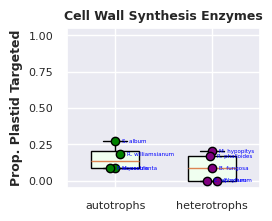

group                         targeting_unknown  notarget  target     ratio
metabolism                                                                 
autotroph   M. esculenta                    0.0      11.0     1.0  0.083333
            P. equestris                    0.0      11.0     1.0  0.083333
            R. williamsianum                1.0       9.0     2.0  0.181818
            S. album                        1.0       8.0     3.0  0.272727
heterotroph B. fungosa                      0.0      11.0     1.0  0.083333
            E. aphyllum                     1.0      11.0     0.0  0.000000
            E. roseum                       0.0      12.0     0.0  0.000000
            M. hypopitys                    2.0       8.0     2.0  0.200000
            R. phalloides                   0.0      10.0     2.0  0.166667


/tmp/ipykernel_22831/785858292.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(columns, labels= labels[0:2:1], patch_artist=True,widths=0.5, showfliers=False, zorder=1)


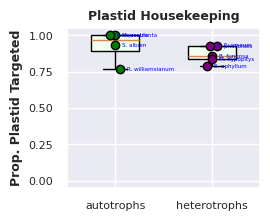

group                         targeting_unknown  notarget  target     ratio
metabolism                                                                 
autotroph   M. esculenta                    0.0       0.0    15.0  1.000000
            P. equestris                    0.0       0.0    15.0  1.000000
            R. williamsianum                2.0       3.0    10.0  0.769231
            S. album                        0.0       1.0    14.0  0.933333
heterotroph B. fungosa                      1.0       2.0    12.0  0.857143
            E. aphyllum                     1.0       3.0    11.0  0.785714
            E. roseum                       1.0       1.0    13.0  0.928571
            M. hypopitys                    3.0       2.0    10.0  0.833333
            R. phalloides                   2.0       1.0    12.0  0.923077


In [19]:
#plot plastid targeting predictions

chloroaaRS = cmetacountstsimple['cytosolic'].assign(ratio=lambda cmetacountstsimple: cmetacountstsimple.target/(cmetacountstsimple.notarget + cmetacountstsimple.target)).sort_index()
aaRSspecies = [chloroaaRS.loc['autotroph',].index.values.tolist(),chloroaaRS.loc['heterotroph',].index.values.tolist()]

chloroaaRSdata = [chloroaaRS.loc['autotroph','ratio'].values.tolist(),chloroaaRS.loc['heterotroph','ratio'].values.tolist()]
chloroaaRSlabels = ['autotrophs', 'heterotrophs', 'Prop. Plastid Targeted','Canonical Cytosolic aaRS','Plastid_ProportionRetargetedchloro_cytaaRS.svg']
boxplotnames(chloroaaRSdata,chloroaaRSlabels,aaRSspecies,'honeydew')
print(chloroaaRS )

chloromitocontrol = cmetacountstsimple['mitochondrial control'].assign(ratio=lambda cmetacountstsimple: cmetacountstsimple.target/(cmetacountstsimple.notarget + cmetacountstsimple.target)).sort_index()
chloromitocontroldata = [chloromitocontrol.loc['autotroph','ratio'].values.tolist(),chloromitocontrol.loc['heterotroph','ratio'].values.tolist()]
chloromitocontrollabels = [chloroaaRS.loc['autotroph',].index.values.tolist(),chloroaaRS.loc['heterotroph',].index.values.tolist()]
chloromitocontrollabels = ['autotrophs', 'heterotrophs', 'Prop. Plastid Targeted','Mitochondrial OXPHOS','Plastid_ProportionRetargetedchloro_OXPHOS.svg']
boxplotnames(chloromitocontroldata,chloromitocontrollabels,aaRSspecies,'honeydew')
print(chloromitocontrol)
print(aaRSspecies)
print(chloromitocontroldata)

chlorocytocontrol = cmetacountstsimple['cytosolic control'].assign(ratio=lambda cmetacountstsimple: cmetacountstsimple.target/(cmetacountstsimple.notarget + cmetacountstsimple.target)).sort_index()
chlorocytocontroldata = [chlorocytocontrol.loc['autotroph','ratio'].values.tolist(),chlorocytocontrol.loc['heterotroph','ratio'].values.tolist()]
chlorocytocontrollabels = ['autotrophs', 'heterotrophs', 'Prop. Plastid Targeted','Cell Wall Synthesis Enzymes','Plastid_ProportionRetargetedchloro_cellwall.svg']
boxplotnames(chlorocytocontroldata,chlorocytocontrollabels,aaRSspecies,'honeydew')
print(chlorocytocontrol )

chlorochlorocontrols = cmetacountstsimple['plastid control'].assign(ratio=lambda cmetacountstsimple: cmetacountstsimple.target/(cmetacountstsimple.notarget + cmetacountstsimple.target)).sort_index()
chlorochlorocontrols
chlorochlorocontrolsdata = [chlorochlorocontrols.loc['autotroph','ratio'].values.tolist(),chlorochlorocontrols.loc['heterotroph','ratio'].values.tolist()]
chlorochlorocontrolslabels = ['autotrophs', 'heterotrophs', 'Prop. Plastid Targeted','Plastid Housekeeping',"Plastid_ProportionRetargeted_PlastidHousekeeping.svg"]
boxplotnames(chlorochlorocontrolsdata,chlorochlorocontrolslabels,aaRSspecies,'honeydew')
print(chlorochlorocontrols)




In [21]:


#means
print("aaRS_auto",np.round(np.mean(chloroaaRS.loc['autotroph','ratio'].values.tolist()),3),
"aaRS_hetero",np.round(np.mean(chloroaaRS.loc['heterotroph','ratio'].values.tolist()),3),"\n"
"mitocontrols_auto",np.round(np.mean(chloromitocontrol.loc['autotroph','ratio'].values.tolist()),3),
"mitocontrols_hetero",np.round(np.mean(chloromitocontrol.loc['heterotroph','ratio'].values.tolist()),3),"\n",
"cytocontrols_auto",np.round(np.mean(chlorocytocontrol.loc['autotroph','ratio'].values.tolist()),3),
"cytocontrols_hetero",np.round(np.mean(chlorocytocontrol.loc['heterotroph','ratio'].values.tolist()),3),"\n"
"chlorocontrols_auto",np.round(np.mean(chlorochlorocontrols.loc['autotroph','ratio'].values.tolist()),3),
"chlorocontrols_hetero",np.round(np.mean(chlorochlorocontrols.loc['heterotroph','ratio'].values.tolist()),3))

aaRS_auto 0.09 aaRS_hetero 0.152 
mitocontrols_auto 0.081 mitocontrols_hetero 0.083 
 cytocontrols_auto 0.155 cytocontrols_hetero 0.09 
chlorocontrols_auto 0.926 chlorocontrols_hetero 0.866


In [ ]:

## Statistics
## Statistics
#normality
print(np.round(st.shapiro(chloroaaRS.loc['autotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(chloroaaRS.loc['heterotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(chloromitocontrol.loc['autotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(chloromitocontrol.loc['heterotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(chlorocytocontrol.loc['autotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(chlorocytocontrol.loc['heterotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(chlorochlorocontrols.loc['autotroph','ratio'].values.tolist())[1],3),
np.round(st.shapiro(chlorochlorocontrols.loc['heterotroph','ratio'].values.tolist())[1],3)
 
# #t-test
stat1, pvalue1 = st.ttest_ind(chloroaaRS.loc['autotroph','ratio'].values.tolist(),chloroaaRS.loc['heterotroph','ratio'].values.tolist(),equal_var=False, alternative='less')
stat2, pvalue2 = st.ttest_ind(chloromitocontrol.loc['autotroph','ratio'].values.tolist(),chloromitocontrol.loc['heterotroph','ratio'].values.tolist(),equal_var=False,alternative='less')
stat3, pvalue3 =st.ttest_ind(chlorocytocontrol.loc['autotroph','ratio'].values.tolist(),chlorocytocontrol.loc['heterotroph','ratio'].values.tolist(),equal_var=False,alternative="less")
stat4, pvalue4 =st.ttest_ind(chlorochlorocontrols.loc['autotroph','ratio'].values.tolist(),chlorochlorocontrols.loc['heterotroph','ratio'].values.tolist(),equal_var=False,alternative="less")
print("auto vs. hetero aaRS: ", pvalue1,"\n",
    "auto vs. hetero OXPHOS: ", np.round(pvalue2,3), "\n",
    "auto vs. hetero cell wall: ", pvalue3, "\n",
    "auto vs. hetero plastid housekeeping: ", pvalue4, "\n",)


In [ ]:
#non-parametric test
stat1, pvalue1 = st.mannwhitneyu(chloroaaRS.loc['autotroph','ratio'].values.tolist(),chloroaaRS.loc['heterotroph','ratio'].values.tolist())
stat2, pvalue2 = st.mannwhitneyu(chlorochlorocontrols.loc['autotroph','ratio'].values.tolist(),chlorochlorocontrols.loc['heterotroph','ratio'].values.tolist())
stat3, pvalue3 =st.mannwhitneyu(chlorocytocontrol.loc['autotroph','ratio'].values.tolist(),chlorocytocontrol.loc['heterotroph','ratio'].values.tolist())

print("auto vs. hetero aaRS: ", np.round(pvalue1,3),"\n",
    "auto vs. hetero plastid control: ", np.round(pvalue2,3), "\n",
    "auto vs. hetero cell wall: ",np.round(pvalue3,3), "\n")

In [ ]:
#Fisher's exact
print("############aaRS##########")
fisher(chloroaaRS,'metabolism',['notarget','target'])

print("############OXPHOS##########")
fisher(chloromitocontrol,'metabolism',['notarget','target'])

print("############Cell Wall##########")
fisher(chlorocytocontrol,'metabolism',['notarget','target'])